# number plate scanner

This notebook detects number plates from images using `easyocr` and `opencv`.

In [1]:
# 📦 Install ALL dependencies in one go
import sys
print("Installing dependencies... This may take a minute.")
!"{sys.executable}" -m pip install easyocr opencv-python matplotlib ipywidgets --user
print("✅ Installation complete. Please restart the kernel if you see import errors.")

Installing dependencies... This may take a minute.
  Obtaining dependency information for easyocr from https://files.pythonhosted.org/packages/bb/84/4a2cab0e6adde6a85e7ba543862e5fc0250c51f3ac721a078a55cdcff250/easyocr-1.7.2-py3-none-any.whl.metadata
  Using cached easyocr-1.7.2-py3-none-any.whl.metadata (10 kB)
  Obtaining dependency information for ipywidgets from https://files.pythonhosted.org/packages/56/6d/0d9848617b9f753b87f214f1c682592f7ca42de085f564352f10f0843026/ipywidgets-8.1.8-py3-none-any.whl.metadata
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Obtaining dependency information for torch from https://files.pythonhosted.org/packages/6f/3d/c87b33c5f260a2a8ad68da7147e105f05868c281c63d65ed85aa4da98c66/torch-2.10.0-cp311-cp311-win_amd64.whl.metadata
  Using cached torch-2.10.0-cp311-cp311-win_amd64.whl.metadata (31 kB)
  Obtaining dependency information for torchvision>=0.5 from https://files.pythonhosted.org/packages/23/19/55b28aecdc7f38df57b8eb55eb0b14a6


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import cv2
import matplotlib.pyplot as plt
import easyocr
import re
import os
import ipywidgets as widgets
from IPython.display import display, HTML

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [3]:
# 📍 Indian State Code Mapping
state_map = {
    'AP': 'Andhra Pradesh', 'AR': 'Arunachal Pradesh', 'AS': 'Assam', 'BR': 'Bihar',
    'CG': 'Chhattisgarh', 'CH': 'Chandigarh', 'DL': 'Delhi', 'GA': 'Goa', 'GJ': 'Gujarat',
    'HR': 'Haryana', 'HP': 'Himachal Pradesh', 'JH': 'Jharkhand', 'JK': 'Jammu and Kashmir',
    'KA': 'Karnataka', 'KL': 'Kerala', 'LA': 'Ladakh', 'LD': 'Lakshadweep', 'MH': 'Maharashtra',
    'ML': 'Meghalaya', 'MN': 'Manipur', 'MP': 'Madhya Pradesh', 'MZ': 'Mizoram', 'NL': 'Nagaland',
    'OD': 'Odisha', 'PB': 'Punjab', 'PY': 'Puducherry', 'RJ': 'Rajasthan', 'SK': 'Sikkim',
    'TN': 'Tamil Nadu', 'TR': 'Tripura', 'TS': 'Telangana', 'UK': 'Uttarakhand', 'UP': 'Uttar Pradesh',
    'WB': 'West Bengal'
}

# 🧠 Recognize plate and predict state
def recognize_state_from_plate(image_path):
    print(f"Processing: {image_path}")
    
    print("📥 Initializing EasyOCR...")
    reader = easyocr.Reader(['en'], gpu=False)
    print("✅ OCR Model Ready!")

    print("📸 Reading image...")
    image = cv2.imread(image_path)
    if image is None:
        print("❌ Failed to read the image.")
        return

    print("🔍 Detecting text...")
    result = reader.readtext(image)

    plate_text = ""
    # Try strict regex first
    for (bbox, text, prob) in result:
        clean_text = text.upper().replace(" ", "").replace("-", "")
        if re.match(r'^[A-Z]{2}[0-9]{1,2}[A-Z]{0,3}[0-9]{4}$', clean_text):
            plate_text = clean_text
            break
            
    # Fallback to loose matching if strict fails
    if not plate_text:
         for (bbox, text, prob) in result:
            clean_text = text.upper().replace(" ", "").replace("-", "")
            # Look for pattern starting with 2 letters and ending with 4 numbers
            if len(clean_text) >= 6 and re.match(r'^[A-Z]{2}', clean_text) and re.search(r'[0-9]{4}$', clean_text):
                 plate_text = clean_text
                 break

    if plate_text:
        state_code = plate_text[:2]
        state = state_map.get(state_code, "Unknown State")
        print(f"\n✅ Detected Plate: {plate_text}")
        print(f"🏷️ Predicted State: {state}")
    else:
        print("❌ No valid number plate found.")
        # Show raw results for debugging
        print("Raw Detections:", [t[1] for t in result])

    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Detected: {plate_text if plate_text else 'None'}")
    plt.show()

Using CPU. Note: This module is much faster with a GPU.


Found 249 images in 'images'
Processing: images\1.jpg
📥 Initializing EasyOCR...
✅ OCR Model Ready!
📸 Reading image...
🔍 Detecting text...


C:\Users\Naveen C\AppData\Roaming\Python\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


❌ No valid number plate found.
Raw Detections: ['3', 'QOuzudd', 'MH1s-TC-554']


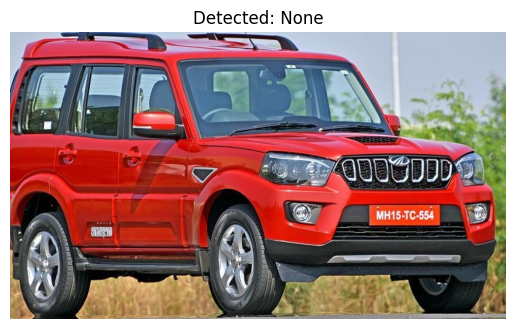

In [4]:
# 📂 Check for existing images
import os

image_folder = 'images'
if os.path.exists(image_folder):
    files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"Found {len(files)} images in '{image_folder}'")
    if files:
        # Process the first image as a test
        if 'os' not in locals(): import os
        test_image = os.path.join(image_folder, files[0])
        recognize_state_from_plate(test_image)
else:
    print(f"'{image_folder}' directory not found. Please upload an image below.")

FileUpload(value=(), accept='.jpg,.jpeg,.png', description='Upload')

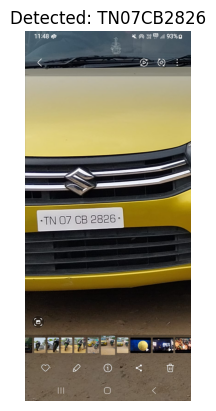

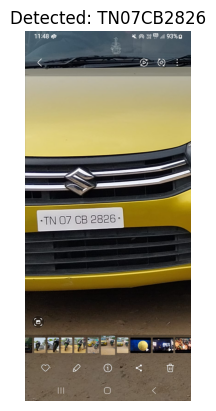

In [7]:
# 📤 Upload Widget for Jupyter
upload_widget = widgets.FileUpload(
    accept='.jpg,.jpeg,.png',
    multiple=False
)

def on_upload_change(change):
    # Get the uploaded file - handle different ipywidgets versions
    if not upload_widget.value:
        return
        
    vals = upload_widget.value
    content = None
    name = "uploaded_image.jpg"
    
    # Try to unpack based on structure
    if isinstance(vals, dict): # ipywidgets < 8
        first_key = next(iter(vals))
        content = vals[first_key]['content']
        name = vals[first_key]['metadata']['name']
    elif isinstance(vals, tuple): # ipywidgets >= 8
        first_file = vals[0]
        # Depending on tuple content, it might be a dict or object
        if hasattr(first_file, 'content'):
            content = first_file.content
            name = first_file.name
        elif isinstance(first_file, dict) and 'content' in first_file:
             content = first_file['content']
             name = first_file.get('name', name)
    
    if content:
        file_path = f"temp_{name}"
        with open(file_path, "wb") as f:
            f.write(content)
        
        print(f"\n📂 File uploaded: {file_path}")
        try:
            recognize_state_from_plate(file_path)
        except NameError:
            print("❌ Error: 'easyocr' is not defined. Please RUN THE CELLS ABOVE first.")

upload_widget.observe(on_upload_change, names='value')

# 🔽 Display uploader
display(HTML("<h3>📤 Upload a number plate image (.jpg/.png):</h3>"))
display(upload_widget)